# Human Activity Recognition using Hidden Markov Models (HMM)

**Project:** ML Techniques 2 - Formative 1  
**Team Members:**
- **KERIE** — iPhone 11, Sensor Logger app, 100Hz sampling rate  
- **[TEAMMATE NAME]** — [Phone Model], [App], [Sampling Rate]  

**Activities:** Standing, Walking, Jumping, Still  
**Approach:** HMM implemented from scratch using NumPy  

---

## 1. Data Loading & Exploration
*(KERIE's Task)*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load the combined dataset
df = pd.read_csv('data/all_activities_combined.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nActivity distribution:")
print(df.groupby('activity')['sample_id'].nunique().to_string())
print(f"\nTotal recordings: {df['sample_id'].nunique()}")
print(f"Total data points: {len(df)}")
df.head()

Dataset shape: (33238, 12)

Columns: ['time', 'seconds_elapsed', 'accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z', 'activity', 'sample_id', 'device', 'sample_rate_ms']

Activity distribution:
activity
jumping     8
standing    7
still       8
walking     8

Total recordings: 31
Total data points: 33238


,time,seconds_elapsed,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,activity,sample_id,device,sample_rate_ms
0,1772639285866917000,0.071917,0.183820,-0.075293,0.092428,0.265162,0.260875,-0.066091,jumping,jumping_1,iPhone 11,10
1,1772639285876994000,0.081994,0.214268,-0.048899,0.140372,0.241630,0.219603,-0.042394,jumping,jumping_1,iPhone 11,10
2,1772639285887071200,0.092071,0.236790,-0.108634,0.171207,0.223481,0.152270,-0.006736,jumping,jumping_1,iPhone 11,10
3,1772639285897149200,0.102149,0.286869,-0.141394,0.159760,0.206100,0.110109,0.025221,jumping,jumping_1,iPhone 11,10
4,1772639285907226000,0.112226,0.204783,-0.132461,0.219001,0.198182,0.102952,0.047138,jumping,jumping_1,iPhone 11,10


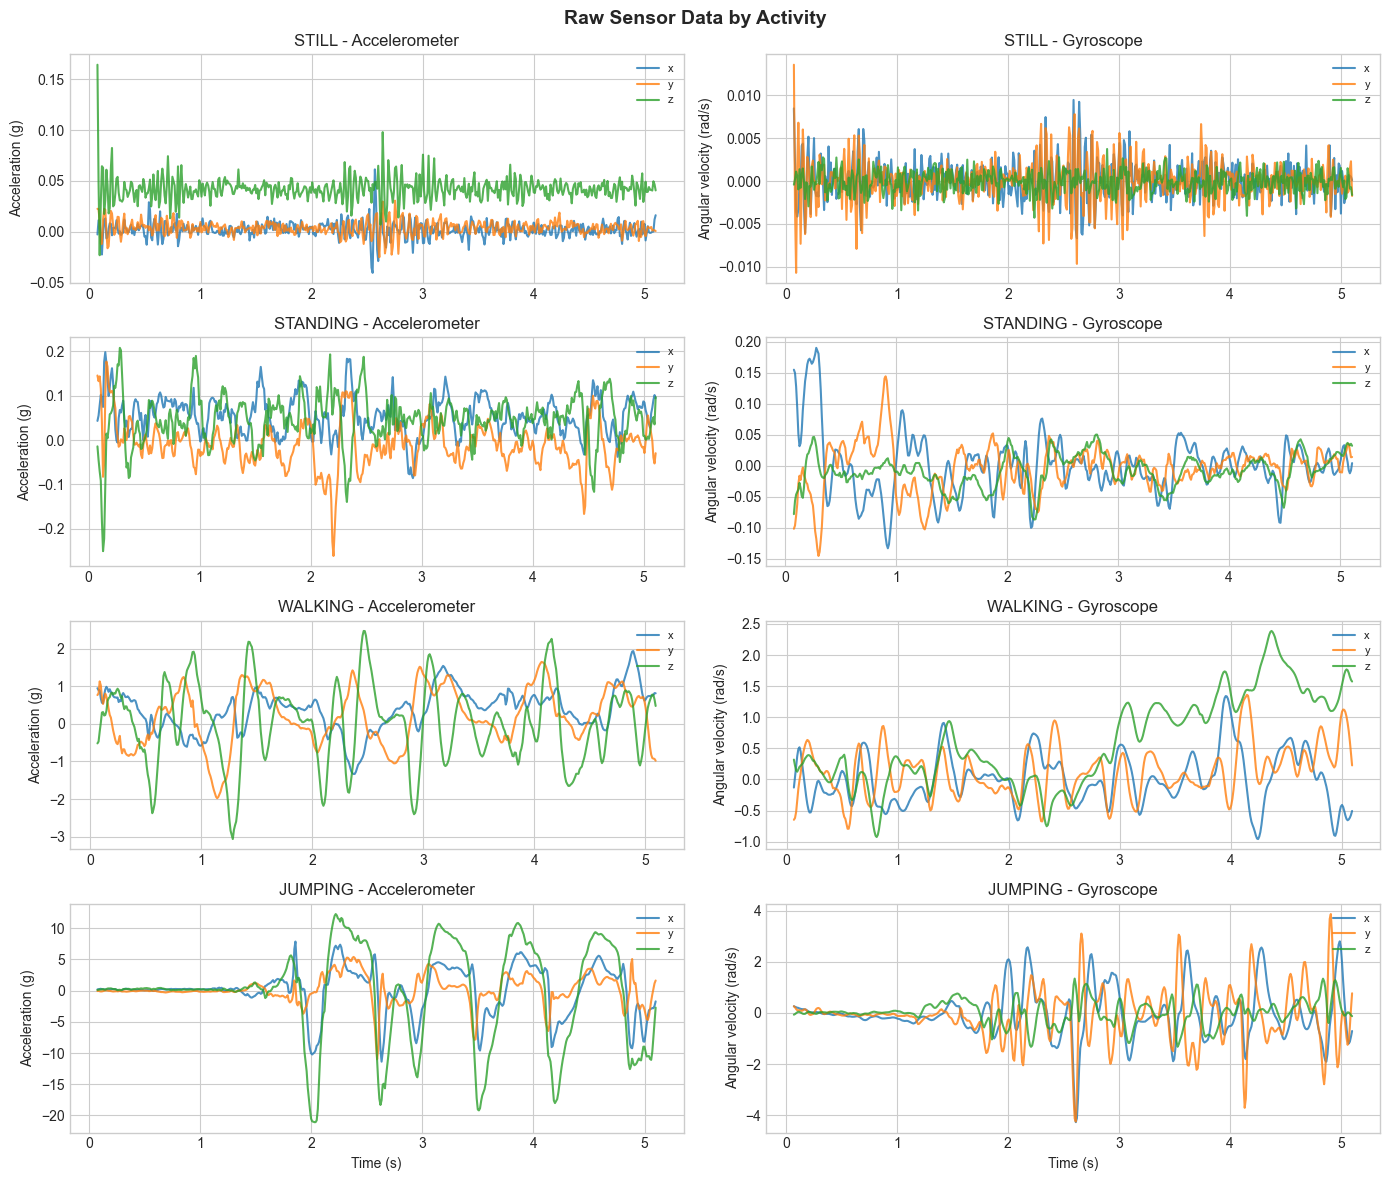

In [3]:
# Visualize raw sensor data for each activity (one sample each)
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
activities = ['still', 'standing', 'walking', 'jumping']

for i, activity in enumerate(activities):
    sample = df[df['activity'] == activity]
    sample_id = sample['sample_id'].unique()[0]
    sample_data = sample[sample['sample_id'] == sample_id].head(500)
    t = sample_data['seconds_elapsed']
    
    # Accelerometer
    axes[i, 0].plot(t, sample_data['accel_x'], label='x', alpha=0.8)
    axes[i, 0].plot(t, sample_data['accel_y'], label='y', alpha=0.8)
    axes[i, 0].plot(t, sample_data['accel_z'], label='z', alpha=0.8)
    axes[i, 0].set_title(f'{activity.upper()} - Accelerometer')
    axes[i, 0].set_ylabel('Acceleration (g)')
    axes[i, 0].legend(loc='upper right', fontsize=8)
    
    # Gyroscope
    axes[i, 1].plot(t, sample_data['gyro_x'], label='x', alpha=0.8)
    axes[i, 1].plot(t, sample_data['gyro_y'], label='y', alpha=0.8)
    axes[i, 1].plot(t, sample_data['gyro_z'], label='z', alpha=0.8)
    axes[i, 1].set_title(f'{activity.upper()} - Gyroscope')
    axes[i, 1].set_ylabel('Angular velocity (rad/s)')
    axes[i, 1].legend(loc='upper right', fontsize=8)

axes[3, 0].set_xlabel('Time (s)')
axes[3, 1].set_xlabel('Time (s)')
plt.suptitle('Raw Sensor Data by Activity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Feature Extraction
*(KERIE's Task)*

From each time window we compute:
- **Time-domain:** mean, variance, standard deviation, signal magnitude area (SMA), correlation between axes
- **Frequency-domain:** dominant frequency, spectral energy, FFT components

In [4]:
# --- Feature Extraction Functions ---

SAMPLING_RATE = 100  # 100 Hz (10ms interval)
WINDOW_SIZE = 100    # 1-second windows (100 samples at 100Hz)
WINDOW_OVERLAP = 50  # 50% overlap

def compute_sma(window, cols):
    """Signal Magnitude Area: sum of absolute means across axes."""
    return sum(window[col].abs().mean() for col in cols)

def compute_correlation(window, col1, col2):
    """Pearson correlation between two axes."""
    if window[col1].std() == 0 or window[col2].std() == 0:
        return 0.0
    corr, _ = pearsonr(window[col1], window[col2])
    return corr if not np.isnan(corr) else 0.0

def compute_fft_features(signal, sampling_rate):
    """Compute dominant frequency and spectral energy from FFT."""
    n = len(signal)
    if n == 0:
        return 0.0, 0.0
    fft_vals = fft(signal)
    fft_magnitude = np.abs(fft_vals[:n // 2])
    freqs = fftfreq(n, d=1.0/sampling_rate)[:n // 2]
    
    # Dominant frequency (skip DC component at index 0)
    if len(fft_magnitude) > 1:
        dominant_idx = np.argmax(fft_magnitude[1:]) + 1
        dominant_freq = freqs[dominant_idx]
    else:
        dominant_freq = 0.0
    
    # Spectral energy
    spectral_energy = np.sum(fft_magnitude ** 2) / n
    
    return dominant_freq, spectral_energy

def extract_features_from_window(window):
    """Extract all features from a single time window."""
    features = {}
    
    accel_cols = ['accel_x', 'accel_y', 'accel_z']
    gyro_cols = ['gyro_x', 'gyro_y', 'gyro_z']
    all_cols = accel_cols + gyro_cols
    
    # --- Time-domain features ---
    for col in all_cols:
        features[f'{col}_mean'] = window[col].mean()
        features[f'{col}_var'] = window[col].var()
        features[f'{col}_std'] = window[col].std()
    
    # Signal Magnitude Area
    features['accel_sma'] = compute_sma(window, accel_cols)
    features['gyro_sma'] = compute_sma(window, gyro_cols)
    
    # Correlation between axes
    features['accel_corr_xy'] = compute_correlation(window, 'accel_x', 'accel_y')
    features['accel_corr_xz'] = compute_correlation(window, 'accel_x', 'accel_z')
    features['accel_corr_yz'] = compute_correlation(window, 'accel_y', 'accel_z')
    features['gyro_corr_xy'] = compute_correlation(window, 'gyro_x', 'gyro_y')
    features['gyro_corr_xz'] = compute_correlation(window, 'gyro_x', 'gyro_z')
    features['gyro_corr_yz'] = compute_correlation(window, 'gyro_y', 'gyro_z')
    
    # --- Frequency-domain features ---
    for col in all_cols:
        dom_freq, spec_energy = compute_fft_features(window[col].values, SAMPLING_RATE)
        features[f'{col}_dom_freq'] = dom_freq
        features[f'{col}_spec_energy'] = spec_energy
    
    return features

print(f"Window size: {WINDOW_SIZE} samples ({WINDOW_SIZE/SAMPLING_RATE}s)")
print(f"Window overlap: {WINDOW_OVERLAP} samples ({WINDOW_OVERLAP/SAMPLING_RATE}s)")
print(f"Sampling rate: {SAMPLING_RATE} Hz")

Window size: 100 samples (1.0s)
Window overlap: 50 samples (0.5s)
Sampling rate: 100 Hz


In [5]:
# --- Apply windowing and extract features from all recordings ---

all_features = []

for sample_id in df['sample_id'].unique():
    sample_data = df[df['sample_id'] == sample_id].sort_values('seconds_elapsed').reset_index(drop=True)
    activity = sample_data['activity'].iloc[0]
    n_rows = len(sample_data)
    
    # Sliding window
    start = 0
    while start + WINDOW_SIZE <= n_rows:
        window = sample_data.iloc[start:start + WINDOW_SIZE]
        features = extract_features_from_window(window)
        features['activity'] = activity
        features['sample_id'] = sample_id
        all_features.append(features)
        start += (WINDOW_SIZE - WINDOW_OVERLAP)

feature_df = pd.DataFrame(all_features)

print(f"Feature extraction complete!")
print(f"Total feature windows: {len(feature_df)}")
print(f"Features per window: {len(feature_df.columns) - 2}")
print(f"\nWindows per activity:")
print(feature_df['activity'].value_counts().to_string())
feature_df.head()

Feature extraction complete!
Total feature windows: 617
Features per window: 38

Windows per activity:
activity
walking     171
still       162
standing    145
jumping     139


,accel_x_mean,accel_x_var,accel_x_std,accel_y_mean,accel_y_var,accel_y_std,accel_z_mean,accel_z_var,accel_z_std,gyro_x_mean,...,accel_z_dom_freq,accel_z_spec_energy,gyro_x_dom_freq,gyro_x_spec_energy,gyro_y_dom_freq,gyro_y_spec_energy,gyro_z_dom_freq,gyro_z_spec_energy,activity,sample_id
0,0.166271,0.006497,0.080602,-0.125104,0.005826,0.076326,0.214402,0.008754,0.093560,-0.085343,...,1.0,5.030114,1.0,1.655625,1.0,0.438600,2.0,0.084952,jumping,jumping_1
1,0.044766,0.141928,0.376733,0.013196,0.149111,0.386149,0.226458,0.067601,0.260002,-0.133516,...,2.0,8.472939,1.0,3.787198,3.0,1.915218,1.0,5.002497,jumping,jumping_1
2,-0.585918,11.459538,3.385194,-0.382096,1.083928,1.041118,-1.907366,45.978967,6.780779,-0.042299,...,2.0,2639.668373,4.0,21.071222,4.0,27.004148,1.0,10.690247,jumping,jumping_1
3,1.036747,19.055458,4.365256,0.898255,7.933378,2.816625,1.383739,84.030818,9.166833,0.075325,...,1.0,4350.879582,1.0,50.325009,9.0,42.300120,2.0,15.943278,jumping,jumping_1
4,0.279143,17.861955,4.226341,1.109252,11.191267,3.345335,0.318180,79.229311,8.901085,0.141104,...,1.0,3931.727919,1.0,100.266430,5.0,81.886133,1.0,18.383115,jumping,jumping_1


In [6]:
# Save extracted features
feature_df.to_csv('data/extracted_features.csv', index=False)
print("Features saved to data/extracted_features.csv")

Features saved to data/extracted_features.csv


## 3. Define HMM Model Components
*(KERIE's Task)*

| Element | Description |
|---------|-------------|
| **Hidden States (Z)** | 4 states: Standing (0), Walking (1), Jumping (2), Still (3) |
| **Observations (X)** | Feature vectors from accelerometer + gyroscope signals |
| **Transition Probabilities (A)** | 4x4 matrix — probability of switching between activities |
| **Emission Probabilities (B)** | Gaussian distributions — P(features \| activity) |
| **Initial State Probabilities (pi)** | Uniform start: each activity equally likely |

In [7]:
# --- Prepare data for HMM ---

# Encode activity labels
activity_labels = ['standing', 'walking', 'jumping', 'still']
activity_to_idx = {a: i for i, a in enumerate(activity_labels)}
idx_to_activity = {i: a for a, i in activity_to_idx.items()}
N_STATES = len(activity_labels)

# Feature columns (exclude activity and sample_id)
feature_cols = [c for c in feature_df.columns if c not in ['activity', 'sample_id']]

# Encode labels
feature_df['label'] = feature_df['activity'].map(activity_to_idx)

# Standardize features
scaler = StandardScaler()
X_all = scaler.fit_transform(feature_df[feature_cols].values)
y_all = feature_df['label'].values

print(f"Hidden States (Z): {activity_labels}")
print(f"Number of states: {N_STATES}")
print(f"Observation dimension: {X_all.shape[1]} features")
print(f"Total observation sequences: {X_all.shape[0]}")

Hidden States (Z): ['standing', 'walking', 'jumping', 'still']
Number of states: 4
Observation dimension: 38 features
Total observation sequences: 617


In [8]:
# --- Train/Test Split ---
# Hold out ~20% of samples as unseen data for evaluation

sample_ids = feature_df['sample_id'].values
unique_samples = feature_df['sample_id'].unique()

# Split by sample_id so entire recordings stay together (no data leakage)
np.random.seed(42)
train_samples, test_samples = train_test_split(
    unique_samples, test_size=0.25, random_state=42,
    stratify=[s.split('_')[0] for s in unique_samples]
)

train_mask = feature_df['sample_id'].isin(train_samples)
test_mask = feature_df['sample_id'].isin(test_samples)

X_train = scaler.fit_transform(feature_df.loc[train_mask, feature_cols].values)
y_train = feature_df.loc[train_mask, 'label'].values

X_test = scaler.transform(feature_df.loc[test_mask, feature_cols].values)
y_test = feature_df.loc[test_mask, 'label'].values

print(f"Training set: {len(X_train)} windows from {len(train_samples)} recordings")
print(f"  Train samples: {sorted(train_samples)}")
print(f"\nTest set (unseen): {len(X_test)} windows from {len(test_samples)} recordings")
print(f"  Test samples: {sorted(test_samples)}")
print(f"\nTrain activity distribution:")
for i, a in enumerate(activity_labels):
    print(f"  {a}: {np.sum(y_train == i)} windows")
print(f"\nTest activity distribution:")
for i, a in enumerate(activity_labels):
    print(f"  {a}: {np.sum(y_test == i)} windows")

Training set: 462 windows from 23 recordings
  Train samples: ['jumping_1', 'jumping_2', 'jumping_3', 'jumping_4', 'jumping_5', 'jumping_8', 'standing_0', 'standing_2', 'standing_4', 'standing_5', 'standing_6', 'still_1', 'still_2', 'still_4', 'still_5', 'still_6', 'still_7', 'walking_1', 'walking_3', 'walking_5', 'walking_6', 'walking_7', 'walking_8']

Test set (unseen): 155 windows from 8 recordings
  Test samples: ['jumping_6', 'jumping_7', 'standing_3', 'standing_7', 'still_3', 'still_8', 'walking_2', 'walking_4']

Train activity distribution:
  standing: 104 windows
  walking: 132 windows
  jumping: 104 windows
  still: 122 windows

Test activity distribution:
  standing: 41 windows
  walking: 39 windows
  jumping: 35 windows
  still: 40 windows


## 4. HMM Implementation (From Scratch with NumPy)

### 4a. Baum-Welch Algorithm (Training)
*(KERIE's Task)*

The Baum-Welch algorithm (a special case of EM) iteratively estimates:
- **A** — transition probability matrix
- **B** — emission parameters (Gaussian: means and covariances per state)
- **pi** — initial state probabilities

In [ ]:
class GaussianHMM:
    """
    Hidden Markov Model with Gaussian emissions, implemented from scratch.
    
    Parameters:
        n_states: Number of hidden states
        n_features: Dimensionality of observation vectors
    
    Components:
        pi: Initial state probabilities (n_states,)
        A:  Transition probability matrix (n_states x n_states)
        means: Emission means per state (n_states x n_features)
        covars: Emission covariances per state (n_states x n_features x n_features)
    """
    
    def __init__(self, n_states, n_features):
        self.n_states = n_states
        self.n_features = n_features
        
        # Initialize pi (uniform)
        self.pi = np.ones(n_states) / n_states
        
        # Initialize A (slight self-transition bias — activities tend to persist)
        self.A = np.full((n_states, n_states), 0.05 / (n_states - 1))
        np.fill_diagonal(self.A, 0.95)
        # Normalize rows
        self.A /= self.A.sum(axis=1, keepdims=True)
        
        # Initialize emission parameters (will be set from data)
        self.means = np.zeros((n_states, n_features))
        self.covars = np.array([np.eye(n_features) for _ in range(n_states)])
    
    def _initialize_from_data(self, X, labels):
        """Initialize emission parameters from labeled training data."""
        for s in range(self.n_states):
            mask = labels == s
            if mask.sum() > 0:
                self.means[s] = X[mask].mean(axis=0)
                cov = np.cov(X[mask].T)
                self.covars[s] = cov + 1e-3 * np.eye(self.n_features)
    
    def _gaussian_log_prob(self, x, mean, covar):
        """Log probability of observation x under a multivariate Gaussian."""
        d = len(mean)
        diff = x - mean
        try:
            L = np.linalg.cholesky(covar)
            solve = np.linalg.solve(L, diff)
            log_det = 2 * np.sum(np.log(np.diag(L)))
            log_prob = -0.5 * (d * np.log(2 * np.pi) + log_det + np.dot(solve, solve))
        except np.linalg.LinAlgError:
            covar_reg = covar + 1e-2 * np.eye(d)
            L = np.linalg.cholesky(covar_reg)
            solve = np.linalg.solve(L, diff)
            log_det = 2 * np.sum(np.log(np.diag(L)))
            log_prob = -0.5 * (d * np.log(2 * np.pi) + log_det + np.dot(solve, solve))
        return log_prob
    
    def _compute_log_emission(self, X):
        """Compute log emission probabilities for all observations and states."""
        T = len(X)
        log_B = np.zeros((T, self.n_states))
        for t in range(T):
            for s in range(self.n_states):
                log_B[t, s] = self._gaussian_log_prob(X[t], self.means[s], self.covars[s])
        return log_B
    
    def _forward(self, log_B):
        """Forward algorithm (in log space for numerical stability)."""
        T = len(log_B)
        log_alpha = np.full((T, self.n_states), -np.inf)
        log_alpha[0] = np.log(self.pi + 1e-300) + log_B[0]
        log_A = np.log(self.A + 1e-300)
        for t in range(1, T):
            for j in range(self.n_states):
                log_alpha[t, j] = self._logsumexp(log_alpha[t-1] + log_A[:, j]) + log_B[t, j]
        return log_alpha
    
    def _backward(self, log_B):
        """Backward algorithm (in log space)."""
        T = len(log_B)
        log_beta = np.full((T, self.n_states), -np.inf)
        log_beta[T-1] = 0.0
        log_A = np.log(self.A + 1e-300)
        for t in range(T-2, -1, -1):
            for i in range(self.n_states):
                log_beta[t, i] = self._logsumexp(
                    log_A[i, :] + log_B[t+1, :] + log_beta[t+1, :]
                )
        return log_beta
    
    @staticmethod
    def _logsumexp(log_vals):
        """Numerically stable log-sum-exp."""
        max_val = np.max(log_vals)
        if max_val == -np.inf:
            return -np.inf
        return max_val + np.log(np.sum(np.exp(log_vals - max_val)))
    
    def _compute_gamma_xi(self, log_alpha, log_beta, log_B):
        """Compute gamma (state posteriors) and xi (transition posteriors)."""
        T = len(log_B)
        log_A = np.log(self.A + 1e-300)
        log_gamma = log_alpha + log_beta
        for t in range(T):
            log_gamma[t] -= self._logsumexp(log_gamma[t])
        gamma = np.exp(log_gamma)
        xi = np.zeros((T-1, self.n_states, self.n_states))
        for t in range(T-1):
            log_xi_t = np.zeros((self.n_states, self.n_states))
            for i in range(self.n_states):
                for j in range(self.n_states):
                    log_xi_t[i, j] = (log_alpha[t, i] + log_A[i, j] + 
                                       log_B[t+1, j] + log_beta[t+1, j])
            log_norm = self._logsumexp(log_xi_t.flatten())
            xi[t] = np.exp(log_xi_t - log_norm)
        return gamma, xi
    
    def baum_welch(self, X_sequences, labels_sequences=None, n_iter=20, tol=1e-4):
        """
        Baum-Welch algorithm to train HMM parameters.
        """
        if labels_sequences is not None:
            all_X = np.vstack(X_sequences)
            all_y = np.concatenate(labels_sequences)
            self._initialize_from_data(all_X, all_y)
        
        log_likelihoods = []
        
        for iteration in range(n_iter):
            total_log_likelihood = 0
            gamma_sum_all = np.zeros(self.n_states)
            gamma_sum_all_no_last = np.zeros(self.n_states)
            xi_sum_all = np.zeros((self.n_states, self.n_states))
            gamma_weighted_X = np.zeros((self.n_states, self.n_features))
            gamma_weighted_cov = np.zeros((self.n_states, self.n_features, self.n_features))
            pi_accum = np.zeros(self.n_states)
            
            for X_seq in X_sequences:
                T = len(X_seq)
                if T < 2:
                    continue
                log_B = self._compute_log_emission(X_seq)
                log_alpha = self._forward(log_B)
                log_beta = self._backward(log_B)
                seq_ll = self._logsumexp(log_alpha[-1])
                total_log_likelihood += seq_ll
                gamma, xi = self._compute_gamma_xi(log_alpha, log_beta, log_B)
                pi_accum += gamma[0]
                gamma_sum_all += gamma.sum(axis=0)
                gamma_sum_all_no_last += gamma[:-1].sum(axis=0)
                xi_sum_all += xi.sum(axis=0)
                for s in range(self.n_states):
                    gamma_s = gamma[:, s]
                    gamma_weighted_X[s] += (gamma_s[:, np.newaxis] * X_seq).sum(axis=0)
                    diff = X_seq - self.means[s]
                    gamma_weighted_cov[s] += np.dot((gamma_s[:, np.newaxis] * diff).T, diff)
            
            log_likelihoods.append(total_log_likelihood)
            if iteration > 0:
                improvement = total_log_likelihood - log_likelihoods[-2]
                if abs(improvement) < tol:
                    print(f"  Converged at iteration {iteration + 1} (improvement: {improvement:.6f})")
                    break
            if (iteration + 1) % 5 == 0 or iteration == 0:
                print(f"  Iteration {iteration + 1}: log-likelihood = {total_log_likelihood:.2f}")
            
            n_sequences = len(X_sequences)
            self.pi = pi_accum / n_sequences
            self.pi = np.maximum(self.pi, 1e-300)
            self.pi /= self.pi.sum()
            for i in range(self.n_states):
                denom = gamma_sum_all_no_last[i]
                if denom > 0:
                    self.A[i] = xi_sum_all[i] / denom
                self.A[i] = np.maximum(self.A[i], 1e-300)
                self.A[i] /= self.A[i].sum()
            for s in range(self.n_states):
                denom = gamma_sum_all[s]
                if denom > 0:
                    self.means[s] = gamma_weighted_X[s] / denom
                    self.covars[s] = gamma_weighted_cov[s] / denom + 1e-3 * np.eye(self.n_features)
        
        return log_likelihoods
    
    # =========================================================================
    # TODO [TEAMMATE]: Implement the Viterbi algorithm
    # =========================================================================
    # Implement viterbi(self, X) method:
    #   - Input: X = observation sequence (T x n_features)
    #   - Output: best_path (array of state indices), best_score (log-probability)
    #   - Steps:
    #     1. Compute log emission probs: log_B = self._compute_log_emission(X)
    #     2. Initialize Viterbi table V[0] = log(pi) + log_B[0]
    #     3. Recursion: V[t,j] = max_i(V[t-1,i] + log(A[i,j])) + log_B[t,j]
    #     4. Store backpointers to track which state gave the max
    #     5. Backtrack from best final state to recover full path
    #
    # Also implement predict(self, X) that calls viterbi and returns the path
    # =========================================================================

print("GaussianHMM class defined (from scratch with NumPy).")
print("Includes: Baum-Welch (training)")
print("TODO [TEAMMATE]: Implement viterbi() and predict() methods")

In [10]:
# --- Prepare sequences for training ---
# Group windows by sample_id to form sequences

train_df = feature_df[feature_df['sample_id'].isin(train_samples)].copy()

X_sequences = []
y_sequences = []

for sample_id in train_samples:
    mask = train_df['sample_id'] == sample_id
    X_seq = scaler.transform(train_df.loc[mask, feature_cols].values)
    y_seq = train_df.loc[mask, 'label'].values
    if len(X_seq) >= 2:
        X_sequences.append(X_seq)
        y_sequences.append(y_seq)

print(f"Training sequences: {len(X_sequences)}")
print(f"Sequence lengths: {[len(s) for s in X_sequences]}")

Training sequences: 23
Sequence lengths: [20, 20, 19, 19, 20, 17, 20, 17, 20, 22, 20, 17, 17, 20, 17, 25, 20, 30, 20, 20, 20, 20, 22]


In [11]:
# --- Train the HMM using Baum-Welch ---

hmm = GaussianHMM(n_states=N_STATES, n_features=len(feature_cols))

print("Training HMM with Baum-Welch algorithm...")
print(f"States: {activity_labels}")
print(f"Features: {len(feature_cols)}")
print()

log_likelihoods = hmm.baum_welch(
    X_sequences, 
    labels_sequences=y_sequences,
    n_iter=30,
    tol=1e-4
)

print(f"\nTraining complete!")
print(f"Final log-likelihood: {log_likelihoods[-1]:.2f}")

Training HMM with Baum-Welch algorithm...
States: ['standing', 'walking', 'jumping', 'still']
Features: 38



  Iteration 1: log-likelihood = 14006.97


  Iteration 5: log-likelihood = 14052.10
  Converged at iteration 6 (improvement: -0.000014)

Training complete!
Final log-likelihood: 14052.10


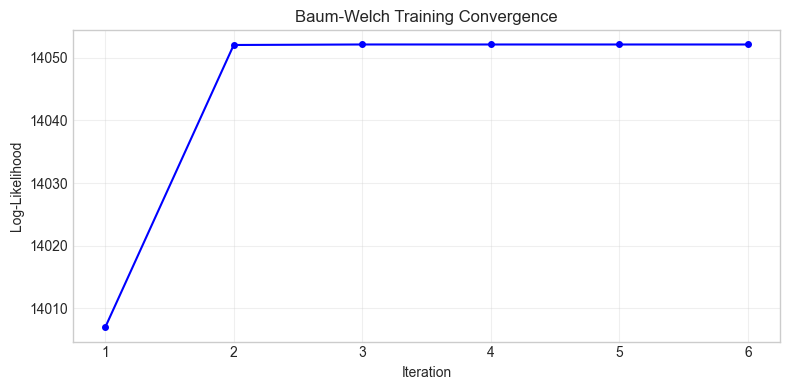

In [12]:
# --- Plot training convergence ---

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(log_likelihoods) + 1), log_likelihoods, 'b-o', markersize=4)
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.title('Baum-Welch Training Convergence')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# --- Display learned model parameters ---

print("Learned Initial State Probabilities (pi):")
for i, a in enumerate(activity_labels):
    print(f"  P(start={a}) = {hmm.pi[i]:.4f}")

print(f"\nLearned Transition Matrix (A):")
A_df = pd.DataFrame(hmm.A, index=activity_labels, columns=activity_labels)
print(A_df.round(4).to_string())

Learned Initial State Probabilities (pi):
  P(start=standing) = 0.2174
  P(start=walking) = 0.2609
  P(start=jumping) = 0.2608
  P(start=still) = 0.2609

Learned Transition Matrix (A):
          standing  walking  jumping  still
standing       1.0   0.0000   0.0000    0.0
walking        0.0   0.9921   0.0079    0.0
jumping        0.0   0.0103   0.9897    0.0
still          0.0   0.0000   0.0000    1.0


### 4b. Transition Matrix Heatmap
*(KERIE's Task)*

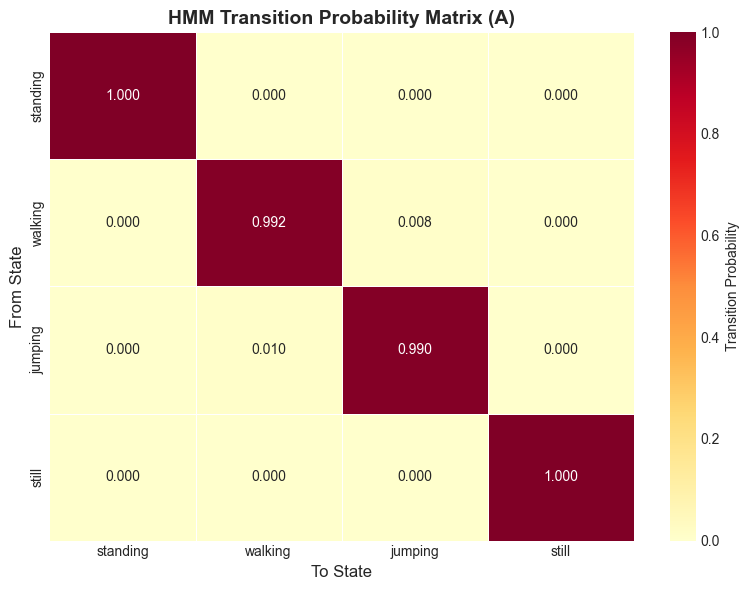


Interpretation:
- High diagonal values indicate activities tend to persist (self-transitions).
- Off-diagonal values show how likely it is to switch between activities.


In [14]:
# --- Transition Matrix Heatmap ---

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    A_df, 
    annot=True, 
    fmt='.3f', 
    cmap='YlOrRd',
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Transition Probability'}
)
ax.set_title('HMM Transition Probability Matrix (A)', fontsize=14, fontweight='bold')
ax.set_xlabel('To State', fontsize=12)
ax.set_ylabel('From State', fontsize=12)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- High diagonal values indicate activities tend to persist (self-transitions).")
print("- Off-diagonal values show how likely it is to switch between activities.")

### 4c. Viterbi Decoding
*(TEAMMATE's Task — implemented in the GaussianHMM class above)*

In [ ]:
# =========================================================================
# TODO [TEAMMATE]: Decode training sequences using Viterbi
# =========================================================================
# After implementing viterbi() and predict() in the GaussianHMM class:
#
# 1. Loop through X_sequences and y_sequences
# 2. For each sequence, call hmm.predict(X_seq)
# 3. Collect predictions and true labels
# 4. Compute training accuracy using accuracy_score()
#
# Example:
#   train_predictions = []
#   train_true = []
#   for X_seq, y_seq in zip(X_sequences, y_sequences):
#       pred = hmm.predict(X_seq)
#       train_predictions.extend(pred)
#       train_true.extend(y_seq)
#   train_acc = accuracy_score(train_true, train_predictions)
# =========================================================================

## 5. Model Evaluation with Unseen Data
*(TEAMMATE's Task)*

**How unseen data was obtained:** We held out 25% of recordings (entire recordings, not individual windows) that were never used during training. These serve as unseen test data.

In [ ]:
# =========================================================================
# TODO [TEAMMATE]: Evaluate on unseen test data
# =========================================================================
# 1. Get test_df from feature_df using test_samples
# 2. For each test sample_id:
#    - Transform features with scaler.transform()
#    - Call hmm.predict() to get predicted states
#    - Collect predictions and true labels
# 3. Compute overall accuracy with accuracy_score()
# 4. Print classification_report() with target_names=activity_labels
# =========================================================================

In [ ]:
# =========================================================================
# TODO [TEAMMATE]: Build evaluation metrics table
# =========================================================================
# Using confusion_matrix(test_true, test_predictions), compute per-activity:
#   - TP, FN, FP, TN from the confusion matrix
#   - Sensitivity = TP / (TP + FN)
#   - Specificity = TN / (TN + FP)
#   - Overall Accuracy
#
# Print table matching this format:
#   Activity | Samples | Sensitivity | Specificity | Accuracy
#   standing |   ...   |    ...      |    ...      |   ...
#   walking  |   ...   |    ...      |    ...      |   ...
#   jumping  |   ...   |    ...      |    ...      |   ...
#   still    |   ...   |    ...      |    ...      |   ...
# =========================================================================

In [ ]:
# =========================================================================
# TODO [TEAMMATE]: Confusion matrix heatmap
# =========================================================================
# Create a heatmap of the confusion matrix using:
#   cm = confusion_matrix(test_true, test_predictions)
#   cm_df = pd.DataFrame(cm, index=activity_labels, columns=activity_labels)
#   sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
# =========================================================================

### Decoded Sequence Plots
*(TEAMMATE's Task)*

In [ ]:
# =========================================================================
# TODO [TEAMMATE]: Plot decoded activity sequences
# =========================================================================
# For each test sample:
#   1. Get the feature sequence and transform with scaler
#   2. Run hmm.predict() to get predicted states
#   3. Plot true vs predicted states using plt.step()
#   4. Use activity_labels for y-tick labels
#   5. Title each subplot with the sample_id
#
# Use plt.subplots(len(test_samples), 1) to create one subplot per sample
# Color: black for true, red dashed for predicted
# =========================================================================

## 6. Analysis and Reflection
*(TEAMMATE's Task — fill in after running)*

### Which activities were easiest or hardest to distinguish?
- *[Fill in based on confusion matrix results]*
- Typically: **jumping** is easiest (high acceleration variance), **still vs standing** is hardest (both low movement)

### How transition probabilities reflect realistic behavior patterns
- High self-transition probabilities (diagonal of A) reflect that people stay in an activity for extended periods
- Transitions like still->standing or standing->walking are more likely than still->jumping

### How sensor noise or sampling rate affected the model
- iPhone 11 sampling at 100Hz provides high-resolution data
- If teammate uses a different phone with different sampling rate, data must be resampled to match
- Accelerometer noise in still/standing activities can cause misclassification

### What improvements could be made
- More training data (especially if teammate adds their recordings)
- Additional features (e.g., jerk, tilt angle)
- Additional sensors (magnetometer, barometer)
- Longer recording sessions for better transition estimation

---
## Summary of Task Division

| Section | KERIE | TEAMMATE |
|---------|-------|----------|
| 1. Data Collection | 31 recordings (iPhone 11, 100Hz) | ~19+ recordings ([Phone], [Rate]) |
| 2. Feature Extraction | Time-domain + frequency-domain features | — |
| 3. Define Model Components | Hidden states, A, B, pi definition | — |
| 4a. Baum-Welch Training | Train + optimize HMM parameters | — |
| 4b. Transition Heatmap | Transition matrix visualization | — |
| 4c. Viterbi Decoding | — | Decode most likely sequences |
| 4d. Decoded Sequence Plots | — | Activity transition plots |
| 5. Evaluation | — | Sensitivity/specificity/accuracy table |
| 6. Analysis & Reflection | — | Discussion of results |